In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier

# === 1. Load dan grouping data ===
df_train = pd.read_csv('/content/drive/MyDrive/Data Mining/train.csv')
df_store = pd.read_csv('/content/drive/MyDrive/Data Mining/store.csv')
df = pd.merge(df_train, df_store, on='Store')

# Cek missing values
print("\n=== Jumlah Missing Values ===")
print(df.isnull().sum())

# Cek duplikat
print("\n=== Jumlah Duplikat ===")
print(df.duplicated().sum())

# === 2. Preprocessing Data ===
df['Date'] = pd.to_datetime(df['Date'])
df['PromoInterval'] = df['PromoInterval'].fillna('')
df['PromoCount'] = df['PromoInterval'].apply(lambda x: len(x.split(',')) if x else 0)
df = df.drop(columns=['PromoInterval'])
df = df.dropna()

# === 3. Extract time information ===
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# === 4. Encoding kategorikal ===
encode_cols = ['StateHoliday', 'StoreType', 'Assortment']
df = pd.get_dummies(df, columns=encode_cols, drop_first=True)

# === 5. Regression Model: Daily Sales Prediction ===
y_reg = df['Sales']
X_reg = df.drop(columns=['Sales', 'Customers', 'Date'])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train_reg, y_train_reg)
y_pred_reg = model_lr.predict(X_test_reg)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("✅ REGRESSION - Daily Sales Prediction")
print("RMSE:", rmse)
print("R²:", r2)

# Train model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_reg, y_train_reg)
y_pred_rf = model_rf.predict(X_test_reg)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("\n🌲 RANDOM FOREST REGRESSOR")
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

# === 6. Model Klasifikasi ===
threshold = df['Sales'].mean()
df['SalesTarget'] = (df['Sales'] > threshold).astype(int)

y_cls = df['SalesTarget']
X_cls = df.drop(columns=['Sales', 'Customers', 'Date', 'SalesTarget'])

# ✅ Scaling before training
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

# Split data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42)

# === Model 1: SVM ===
model_svm = SVC(kernel='rbf', max_iter=2000)
start = time.time()
model_svm.fit(X_train_cls, y_train_cls)
end = time.time()
pred_svm = model_svm.predict(X_test_cls)

print("\n✅ SVM")
print("⏱ Training time:", round(end - start, 2), "second")
print("Accuracy:", accuracy_score(y_test_cls, pred_svm))
print("F1 Score:", f1_score(y_test_cls, pred_svm))

# === Model 2: Decision Tree ===
model_dt = DecisionTreeClassifier()
start = time.time()
model_dt.fit(X_train_cls, y_train_cls)
end = time.time()
pred_dt = model_dt.predict(X_test_cls)

print("\n✅ Decision Tree")
print("⏱ Training time:", round(end - start, 2), "second")
print("Accuracy:", accuracy_score(y_test_cls, pred_dt))
print("F1 Score:", f1_score(y_test_cls, pred_dt))

# === Model 3: KNN ===
model_knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
model_knn.fit(X_train_cls, y_train_cls)
end = time.time()
pred_knn = model_knn.predict(X_test_cls)

print("\n✅ KNN")
print("⏱ Training time", round(end - start, 2), "second")
print("Accuracy:", accuracy_score(y_test_cls, pred_knn))
print("F1 Score:", f1_score(y_test_cls, pred_knn))


/tmp/ipython-input-6-2840653206.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/content/drive/MyDrive/Data Mining/train.csv')



=== Jumlah Missing Values ===
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

=== Jumlah Duplikat ===
0


/tmp/ipython-input-6-2840653206.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DayOfWeek'] = df['Date'].dt.dayofweek
/tmp/ipython-input-6-2840653206.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month
/tmp/ipython-input-6-2840653206.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

✅ REGRESSION - Daily Sales Prediction
RMSE: 2173.7722058126656
R²: 0.6139692709898293

🌲 RANDOM FOREST REGRESSOR
RMSE: 985.355540708523
R²: 0.9206805416330486


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



✅ SVM
⏱ Training time: 73.21 second
Accuracy: 0.6568155890605247
F1 Score: 0.6476184445886692

✅ Decision Tree
⏱ Training time: 1.29 second
Accuracy: 0.8983596953719977
F1 Score: 0.8993050782741504

✅ KNN
⏱ Training time 0.01 second
Accuracy: 0.909182005981562
F1 Score: 0.9109219300500506


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
None

=== Statistik Deskriptif ===
              Store     DayOfWeek         Sales     Customers          Open  \
count  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06  1.017209e+06   
mean   5.584297e+02  3.998341e+00  5.773819e+03  6.331459e+02  8.301067e-01   
std    3.219087e+02  1.997391e+00  3.849926e+03  

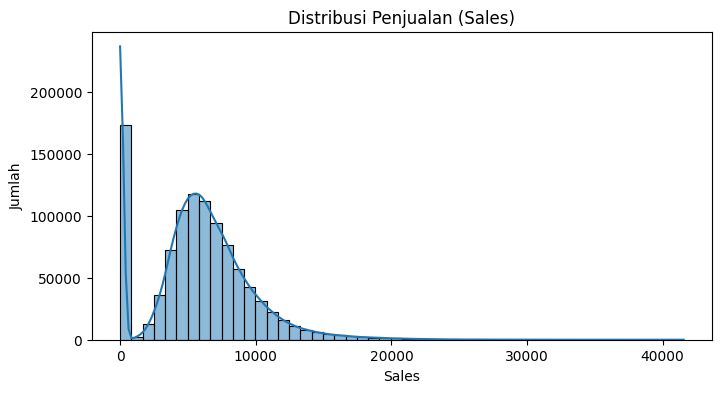

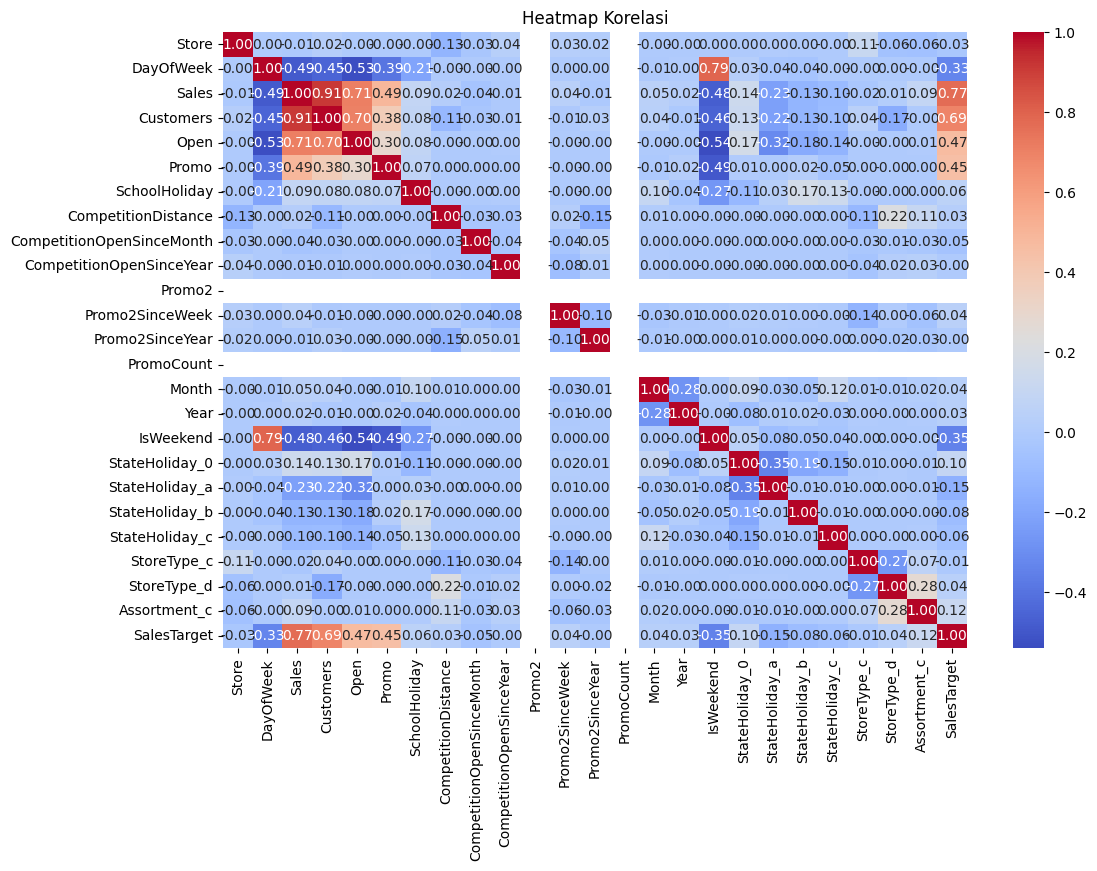

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cek struktur data
print("=== Info Dataset ===")
print(df_train.info())
print("\n=== Statistik Deskriptif ===")
print(df_train.describe())

# Distribusi Sales
plt.figure(figsize=(8, 4))
sns.histplot(df_train['Sales'], bins=50, kde=True)
plt.title('Distribusi Penjualan (Sales)')
plt.xlabel('Sales')
plt.ylabel('Jumlah')
plt.show()

# Korelasi awal (numerik) - dari gabungan dataset setelah merge
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()


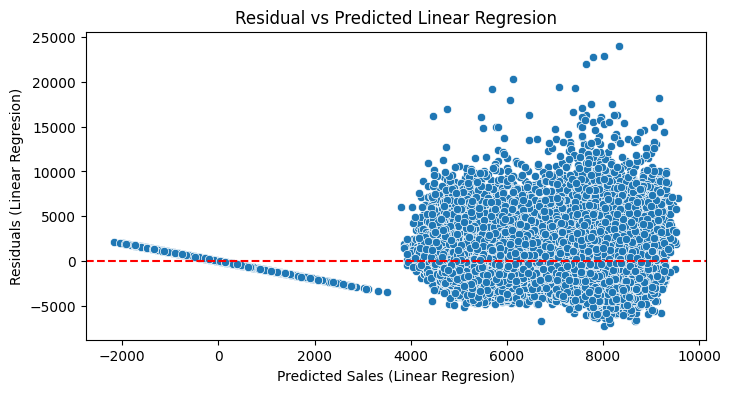

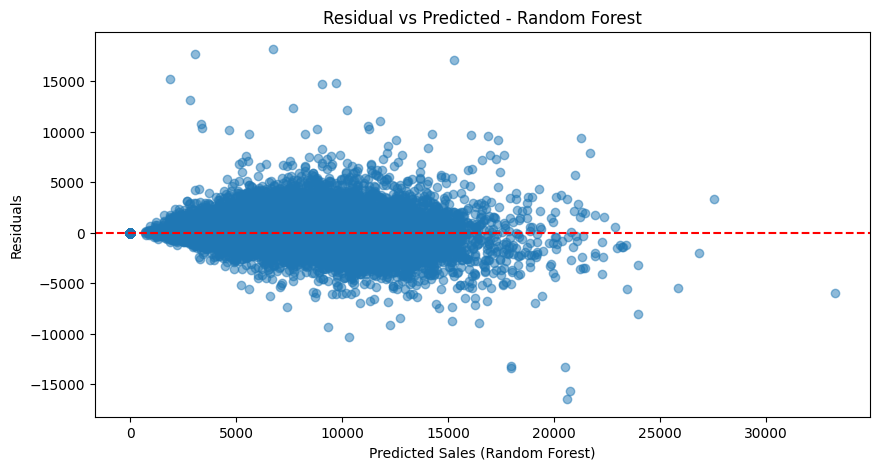

In [ ]:
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred_reg, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual vs Predicted Linear Regresion")
plt.xlabel("Predicted Sales (Linear Regresion)")
plt.ylabel("Residuals (Linear Regresion)")
plt.show()

residuals_rf = y_test_reg - y_pred_rf
plt.figure(figsize=(10,5))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales (Random Forest)')
plt.ylabel('Residuals')
plt.title('Residual vs Predicted - Random Forest')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("\n📊 Confusion Matrix SVM:")
print(confusion_matrix(y_test_cls, pred_svm))

print("\n📋 Classification Report SVM:")
print(classification_report(y_test_cls, pred_svm))



📊 Confusion Matrix SVM:
[[22149  9469]
 [12792 20456]]

📋 Classification Report SVM:
              precision    recall  f1-score   support

           0       0.63      0.70      0.67     31618
           1       0.68      0.62      0.65     33248

    accuracy                           0.66     64866
   macro avg       0.66      0.66      0.66     64866
weighted avg       0.66      0.66      0.66     64866



In [ ]:
import pandas as pd

# Compare 10 predicted results vs actual values
pd.DataFrame({
    'Prediksi Sales': y_pred_reg[:10],
    'Sales Asli': y_test_reg.values[:10]
})


,Prediksi Sales,Sales Asli
0,4448.783032,3900
1,5128.373677,5206
2,8009.597710,8682
3,5122.832590,3447
4,7841.539950,7085
5,6924.291223,7234
6,5479.305985,2768
7,-169.679969,0
8,6896.326625,9298
9,7628.048120,4733


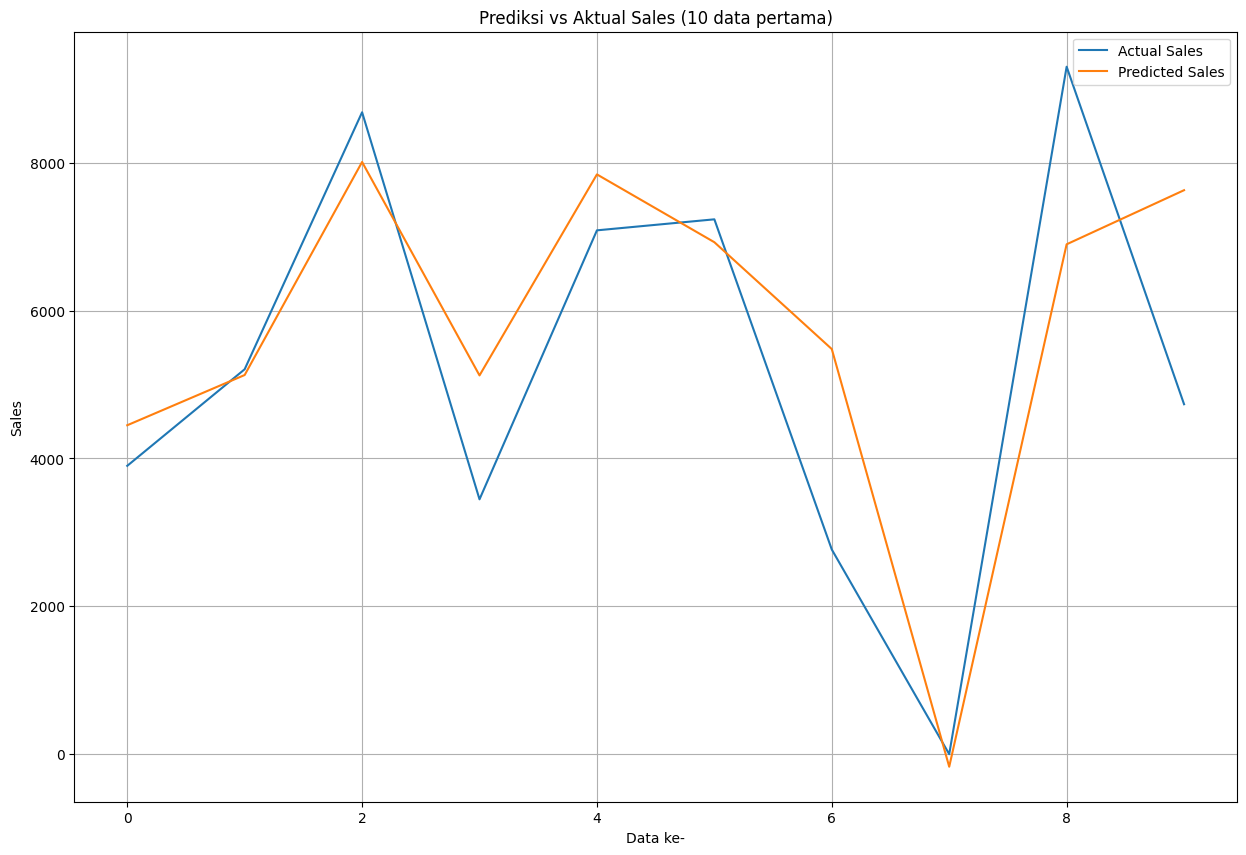

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.plot(y_test_reg.values[:10], label='Actual Sales')
plt.plot(y_pred_reg[:10], label='Predicted Sales')
plt.title('Predicted vs Actual Sales (first 10 data)')
plt.xlabel('Number data')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
sales_per_day = df.groupby('Date')['Sales'].sum().reset_index()
sales_per_day.head()


,Date,Sales
0,2013-01-01,0
1,2013-01-02,2072611
2,2013-01-03,1935685
3,2013-01-04,2053597
4,2013-01-05,1816410


In [ ]:
data = {
    "Model": ["SVM", "Decision Tree", "KNN"],
    "Accuracy": [
        accuracy_score(y_test_cls, pred_svm),
        accuracy_score(y_test_cls, pred_dt),
        accuracy_score(y_test_cls, pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test_cls, pred_svm),
        f1_score(y_test_cls, pred_dt),
        f1_score(y_test_cls, pred_knn)
    ]
}

df_eval = pd.DataFrame(data)
print("\n📊 Comparison of Classification Models:")
print(df_eval)



📊 Perbandingan Model Klasifikasi:
           Model  Accuracy  F1 Score
0            SVM  0.656816  0.647618
1  Decision Tree  0.898791  0.899745
2            KNN  0.909182  0.910922


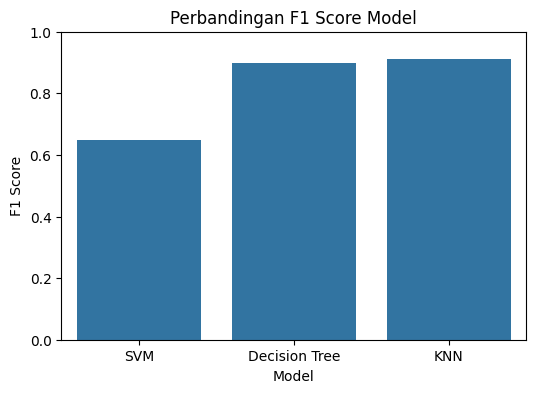

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(data=df_eval, x="Model", y="F1 Score")
plt.title("Perbandingan F1 Score Model")
plt.ylim(0, 1)
plt.show()

In [ ]:
# Grouping
df_cluster = df.groupby('Store')[['Sales', 'Customers', 'Open']].mean().reset_index()

df_cluster.rename(columns={'Open': 'OpenRate'}, inplace=True)

df_cluster.head()

,Store,Sales,Customers,OpenRate
0,2,4122.991507,486.045648,0.832272
1,3,5741.253715,620.286624,0.826964
2,11,6683.955414,940.543524,0.832272
3,14,4555.386412,522.200637,0.826964
4,15,5553.619958,552.130573,0.832272


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Take the column that will be used for clustering
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster[['Sales', 'Customers', 'OpenRate']])


# Clustering with 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_cluster)

# Save cluster labels to dataframe
df_cluster['Cluster'] = labels

# Evaluate cluster
score = silhouette_score(X_cluster, labels)
print("✅ Clustering selesai")
print("Silhouette Score:", score)


✅ Clustering selesai
Silhouette Score: 0.46458186450774647


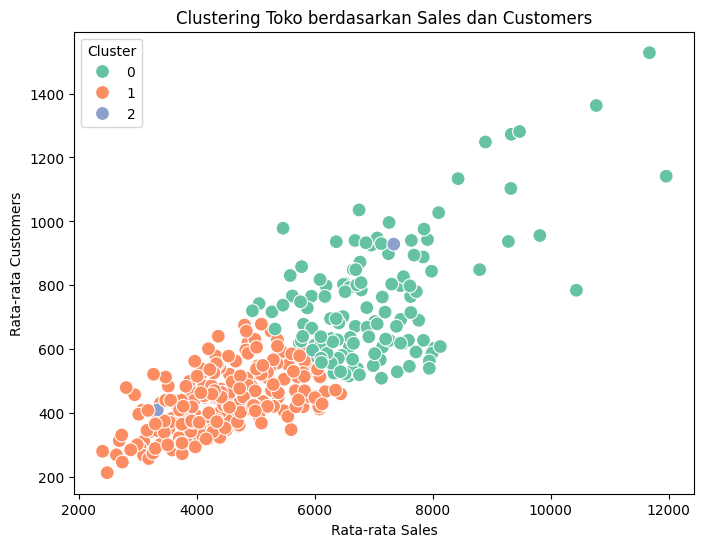

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cluster, x='Sales', y='Customers', hue='Cluster', palette='Set2', s=100)
plt.title('Clustering Toko berdasarkan Sales dan Customers')
plt.xlabel('Rata-rata Sales')
plt.ylabel('Rata-rata Customers')
plt.legend(title='Cluster')
plt.show()


In [ ]:
# Ringkasan isi tiap cluster
summary = df_cluster.groupby('Cluster')[['Sales', 'Customers', 'OpenRate']].mean()
print(summary)


               Sales   Customers  OpenRate
Cluster                                   
0        7041.651872  749.477303  0.824831
1        4512.109529  444.206162  0.824321
2        5301.930998  626.562987  0.937721


📊 Evaluasi KNN dari k=3 sampai 15

k =  3 | Accuracy: 0.9058 | F1 Score: 0.9076
k =  5 | Accuracy: 0.9092 | F1 Score: 0.9109
k =  7 | Accuracy: 0.9100 | F1 Score: 0.9117
k =  9 | Accuracy: 0.9081 | F1 Score: 0.9099
k = 11 | Accuracy: 0.9060 | F1 Score: 0.9078
k = 13 | Accuracy: 0.9044 | F1 Score: 0.9062
k = 15 | Accuracy: 0.9028 | F1 Score: 0.9047


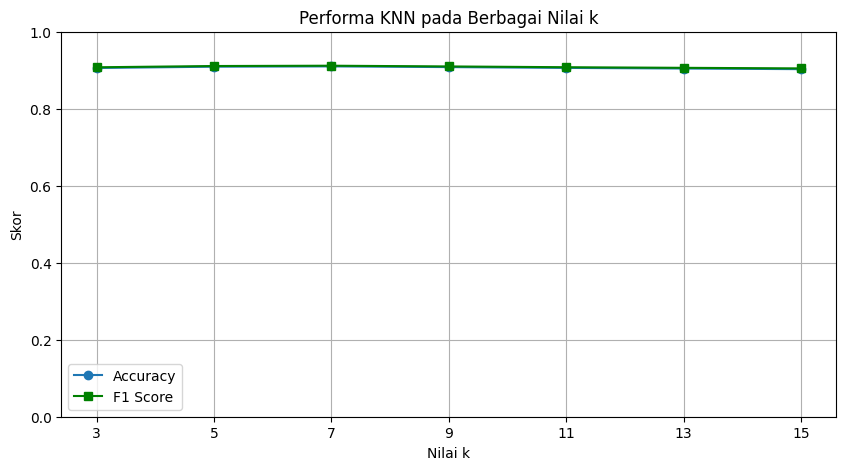

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

# Simpan skor
k_values = list(range(3, 16, 2))
acc_scores = []
f1_scores = []

print("📊 Evaluasi KNN dari k=3 sampai 15\n")

for k in k_values:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_train_cls, y_train_cls)
    pred_knn = model_knn.predict(X_test_cls)

    acc = accuracy_score(y_test_cls, pred_knn)
    f1 = f1_score(y_test_cls, pred_knn)

    acc_scores.append(acc)
    f1_scores.append(f1)

    print(f"k = {k:2} | Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")

# Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(k_values, acc_scores, marker='o', label='Accuracy')
plt.plot(k_values, f1_scores, marker='s', label='F1 Score', color='green')
plt.title('Performa KNN pada Berbagai Nilai k')
plt.xlabel('Nilai k')
plt.ylabel('Skor')
plt.xticks(k_values)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


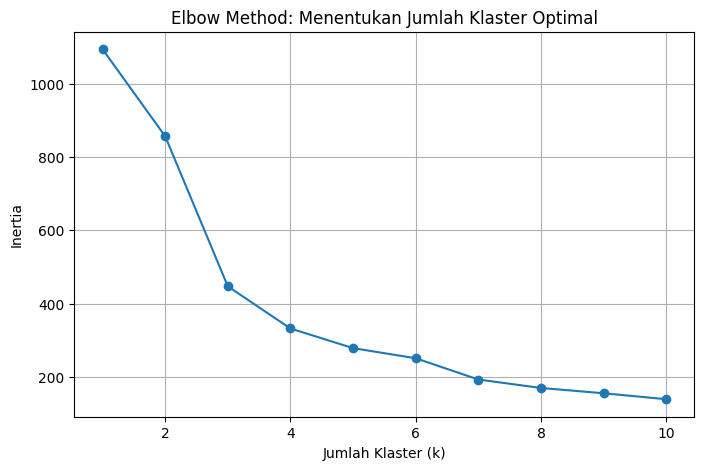

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Ambil fitur yang akan diklaster
df_cluster = df.groupby('Store')[['Sales', 'Customers', 'Open']].mean().reset_index()
df_cluster.rename(columns={'Open': 'OpenRate'}, inplace=True)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster[['Sales', 'Customers', 'OpenRate']])

# 2. Hitung inertia untuk berbagai jumlah klaster
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

# 3. Visualisasi Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method: Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()
